<a href="https://colab.research.google.com/github/Prathama-1/Prosperity-4---Solo42/blob/main/Tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor": "#0f1117",
    "axes.facecolor":   "#1a1d2e",
    "axes.edgecolor":   "#444",
    "axes.labelcolor":  "#ccc",
    "xtick.color":      "#aaa",
    "ytick.color":      "#aaa",
    "text.color":       "#eee",
    "grid.color":       "#2a2d3e",
    "grid.linestyle":   "--",
    "grid.alpha":       0.5,
    "legend.facecolor": "#1a1d2e",
    "legend.edgecolor": "#444",
    "font.family":      "monospace",
})
COLORS = {"EMERALDS": "#00e676", "TOMATOES": "#ff6b6b",
          "Day -1": "#64b5f6", "Day -2": "#ffb74d"}

In [ ]:
p1 = pd.read_csv("prices_round_0_day_-1.csv", sep=";")
p2 = pd.read_csv("prices_round_0_day_-2.csv", sep=";")
t1 = pd.read_csv("trades_round_0_day_-1.csv",  sep=";")
t2 = pd.read_csv("trades_round_0_day_-2.csv",  sep=";")

prices = pd.concat([p1, p2], ignore_index=True)
trades = pd.concat([t1, t2], ignore_index=True)

print("Prices shape:", prices.shape)
print("Trades shape:", trades.shape)
print("\nPrices columns:\n ", list(prices.columns))
print("\nTrades columns:\n ", list(trades.columns))
print("\nProducts:", prices["product"].unique())
print("\nFirst 3 rows of prices:")
print(prices.head(3).to_string())

Prices shape: (40000, 17)
Trades shape: (1219, 7)

Prices columns:
  ['day', 'timestamp', 'product', 'bid_price_1', 'bid_volume_1', 'bid_price_2', 'bid_volume_2', 'bid_price_3', 'bid_volume_3', 'ask_price_1', 'ask_volume_1', 'ask_price_2', 'ask_volume_2', 'ask_price_3', 'ask_volume_3', 'mid_price', 'profit_and_loss']

Trades columns:
  ['timestamp', 'buyer', 'seller', 'symbol', 'currency', 'price', 'quantity']

Products: ['TOMATOES' 'EMERALDS']

First 3 rows of prices:
   day  timestamp   product  bid_price_1  bid_volume_1  bid_price_2  bid_volume_2  bid_price_3  bid_volume_3  ask_price_1  ask_volume_1  ask_price_2  ask_volume_2  ask_price_3  ask_volume_3  mid_price  profit_and_loss
0   -1          0  TOMATOES         4999             5         4998            15          NaN           NaN         5013             5         5014            15          NaN           NaN     5006.0              0.0
1   -1          0  EMERALDS         9992            14         9990            29         

In [ ]:
# ══════════════════════════════════════════════════════════════════
# SECTION 2 — Basic Statistics
# ══════════════════════════════════════════════════════════════════

print("\n" + "="*60)
print("BASIC STATISTICS")
print("="*60)

for prod in ["EMERALDS", "TOMATOES"]:
    df = prices[prices["product"] == prod].copy()
    spread = df["ask_price_1"] - df["bid_price_1"]
    print(f"\n{'─'*40}")
    print(f"  {prod}")
    print(f"{'─'*40}")
    print(f"  Mid price   : {df['mid_price'].min():.1f} – {df['mid_price'].max():.1f}")
    print(f"  Mean / Std  : {df['mid_price'].mean():.2f} / {df['mid_price'].std():.3f}")
    print(f"  Spread      : min={spread.min()}, max={spread.max()}, mean={spread.mean():.2f}")
    print(f"  Bid vol 1   : mean={df['bid_volume_1'].mean():.1f}")
    print(f"  Ask vol 1   : mean={df['ask_volume_1'].mean():.1f}")
    day_means = df.groupby("day")["mid_price"].mean()
    print(f"  Mean by day : {day_means.to_dict()}")

print(f"\n  TRADES summary:")
for sym in ["EMERALDS", "TOMATOES"]:
    td = trades[trades["symbol"] == sym]
    print(f"  {sym}: count={len(td)}, "
          f"price={td['price'].min():.0f}–{td['price'].max():.0f}, "
          f"avg qty={td['quantity'].mean():.1f}")


BASIC STATISTICS

────────────────────────────────────────
  EMERALDS
────────────────────────────────────────
  Mid price   : 9996.0 – 10004.0
  Mean / Std  : 10000.00 / 0.723
  Spread      : min=8, max=16, mean=15.74
  Bid vol 1   : mean=12.5
  Ask vol 1   : mean=12.5
  Mean by day : {-2: 9999.9972, -1: 9999.998}

────────────────────────────────────────
  TOMATOES
────────────────────────────────────────
  Mid price   : 4946.5 – 5036.0
  Mean / Std  : 4992.76 / 19.747
  Spread      : min=5, max=14, mean=13.02
  Bid vol 1   : mean=7.4
  Ask vol 1   : mean=7.4
  Mean by day : {-2: 5007.9485, -1: 4977.56775}

  TRADES summary:
  EMERALDS: count=399, price=9992–10008, avg qty=5.5
  TOMATOES: count=820, price=4943–5040, avg qty=3.5


In [ ]:

# ══════════════════════════════════════════════════════════════════
# SECTION 3 — Order Book Structure
# ══════════════════════════════════════════════════════════════════

print("\n" + "="*60)
print("ORDER BOOK STRUCTURE")
print("="*60)

for label, df_day in [("Day -1", p1), ("Day -2", p2)]:
    print(f"\n  {label}")
    for prod in ["EMERALDS", "TOMATOES"]:
        df = df_day[df_day["product"] == prod].copy()
        df["ret"] = df["mid_price"].diff()
        ac1 = df["ret"].autocorr(lag=1)
        print(f"\n    {prod}:")
        print(f"      ask_price_1 top values : {df['ask_price_1'].value_counts().head(4).to_dict()}")
        print(f"      bid_price_1 top values : {df['bid_price_1'].value_counts().head(4).to_dict()}")
        print(f"      spread top values      : {(df['ask_price_1']-df['bid_price_1']).value_counts().head(3).to_dict()}")
        print(f"      return autocorr lag-1  : {ac1:.3f}  ({'mean-reverting' if ac1 < 0 else 'trending'})")


ORDER BOOK STRUCTURE

  Day -1

    EMERALDS:
      ask_price_1 top values : {10008: 9837, 10000: 163}
      bid_price_1 top values : {9992: 9842, 10000: 158}
      spread top values      : {16: 9679, 8: 321}
      return autocorr lag-1  : -0.490  (mean-reverting)

    TOMATOES:
      ask_price_1 top values : {4995: 346, 4994: 321, 4993: 308, 5000: 303}
      bid_price_1 top values : {4982: 351, 4981: 326, 4980: 326, 4987: 317}
      spread top values      : {13: 5214, 14: 4064, 8: 236}
      return autocorr lag-1  : -0.412  (mean-reverting)

  Day -2

    EMERALDS:
      ask_price_1 top values : {10008: 9830, 10000: 170}
      bid_price_1 top values : {9992: 9837, 10000: 163}
      spread top values      : {16: 9667, 8: 333}
      return autocorr lag-1  : -0.485  (mean-reverting)

    TOMATOES:
      ask_price_1 top values : {5009: 453, 5010: 404, 5011: 398, 5004: 383}
      bid_price_1 top values : {4996: 476, 4998: 397, 4997: 395, 4995: 367}
      spread top values      : {14: 4890

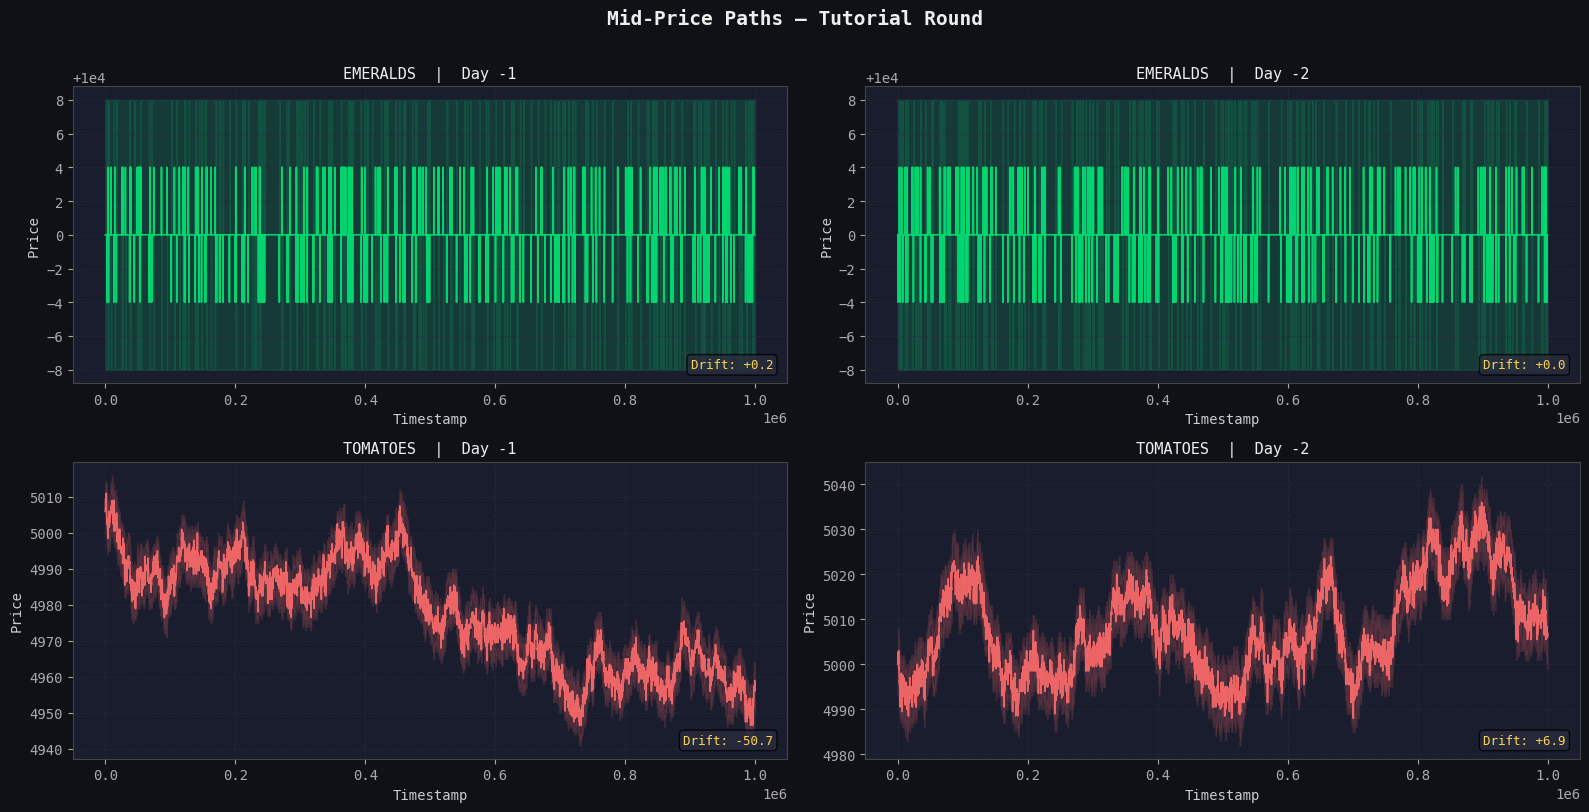

Saved: price_paths.png


In [ ]:
# ══════════════════════════════════════════════════════════════════
# SECTION 4 — Price Path Plots
# ══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle("Mid-Price Paths — Tutorial Round", fontsize=14, fontweight="bold", y=1.01)

for col, (label, df_day) in enumerate([("Day -1", p1), ("Day -2", p2)]):
    for row, prod in enumerate(["EMERALDS", "TOMATOES"]):
        ax = axes[row][col]
        df = df_day[df_day["product"] == prod].sort_values("timestamp")
        color = COLORS[prod]

        ax.plot(df["timestamp"], df["mid_price"], color=color, lw=1.2, alpha=0.9)

        # Shade bid-ask band
        ax.fill_between(df["timestamp"], df["bid_price_1"], df["ask_price_1"],
                        alpha=0.15, color=color, label="Bid-Ask band")

        ax.set_title(f"{prod}  |  {label}", fontsize=11)
        ax.set_xlabel("Timestamp")
        ax.set_ylabel("Price")
        ax.grid(True)

        # Annotate drift
        drift = df["mid_price"].iloc[-20:].mean() - df["mid_price"].iloc[:20].mean()
        ax.text(0.98, 0.05, f"Drift: {drift:+.1f}",
                transform=ax.transAxes, ha="right",
                color="#ffd54f", fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="#2a2d3e", alpha=0.8))

plt.tight_layout()
plt.savefig("price_paths.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: price_paths.png")


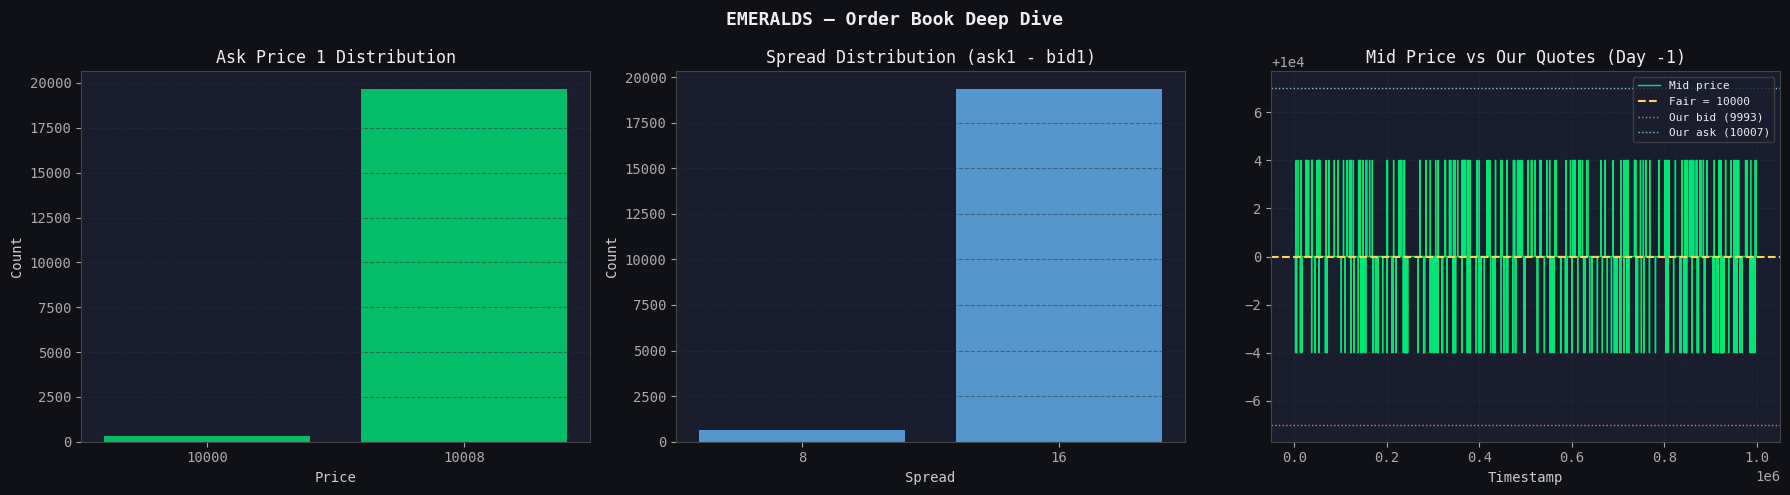

Saved: emeralds_analysis.png


In [ ]:
# ══════════════════════════════════════════════════════════════════
# SECTION 5 — EMERALDS Deep Dive
# ══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("EMERALDS — Order Book Deep Dive", fontsize=13, fontweight="bold")

em_all = prices[prices["product"] == "EMERALDS"].copy()

# Plot 1: Ask price distribution
ax = axes[0]
ask_counts = em_all["ask_price_1"].value_counts().sort_index()
ax.bar(ask_counts.index.astype(str), ask_counts.values,
       color=COLORS["EMERALDS"], alpha=0.8)
ax.set_title("Ask Price 1 Distribution")
ax.set_xlabel("Price")
ax.set_ylabel("Count")
ax.grid(True, axis="y")

# Plot 2: Spread distribution
ax = axes[1]
em_all["spread"] = em_all["ask_price_1"] - em_all["bid_price_1"]
spread_counts = em_all["spread"].value_counts().sort_index()
ax.bar(spread_counts.index.astype(str), spread_counts.values,
       color="#64b5f6", alpha=0.8)
ax.set_title("Spread Distribution (ask1 - bid1)")
ax.set_xlabel("Spread")
ax.set_ylabel("Count")
ax.grid(True, axis="y")

# Plot 3: Mid price zoomed — showing the rare tight moments
ax = axes[2]
em_d1 = p1[p1["product"] == "EMERALDS"].sort_values("timestamp")
ax.plot(em_d1["timestamp"], em_d1["mid_price"],
        color=COLORS["EMERALDS"], lw=1, label="Mid price")
ax.axhline(10000, color="#ffd54f", lw=1.5, ls="--", label="Fair = 10000")
ax.axhline(9993,  color="#ff6b6b", lw=1, ls=":",  label="Our bid (9993)")
ax.axhline(10007, color="#80cbc4", lw=1, ls=":",  label="Our ask (10007)")
ax.set_title("Mid Price vs Our Quotes (Day -1)")
ax.set_xlabel("Timestamp")
ax.legend(fontsize=8)
ax.grid(True)

plt.tight_layout()
plt.savefig("emeralds_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: emeralds_analysis.png")

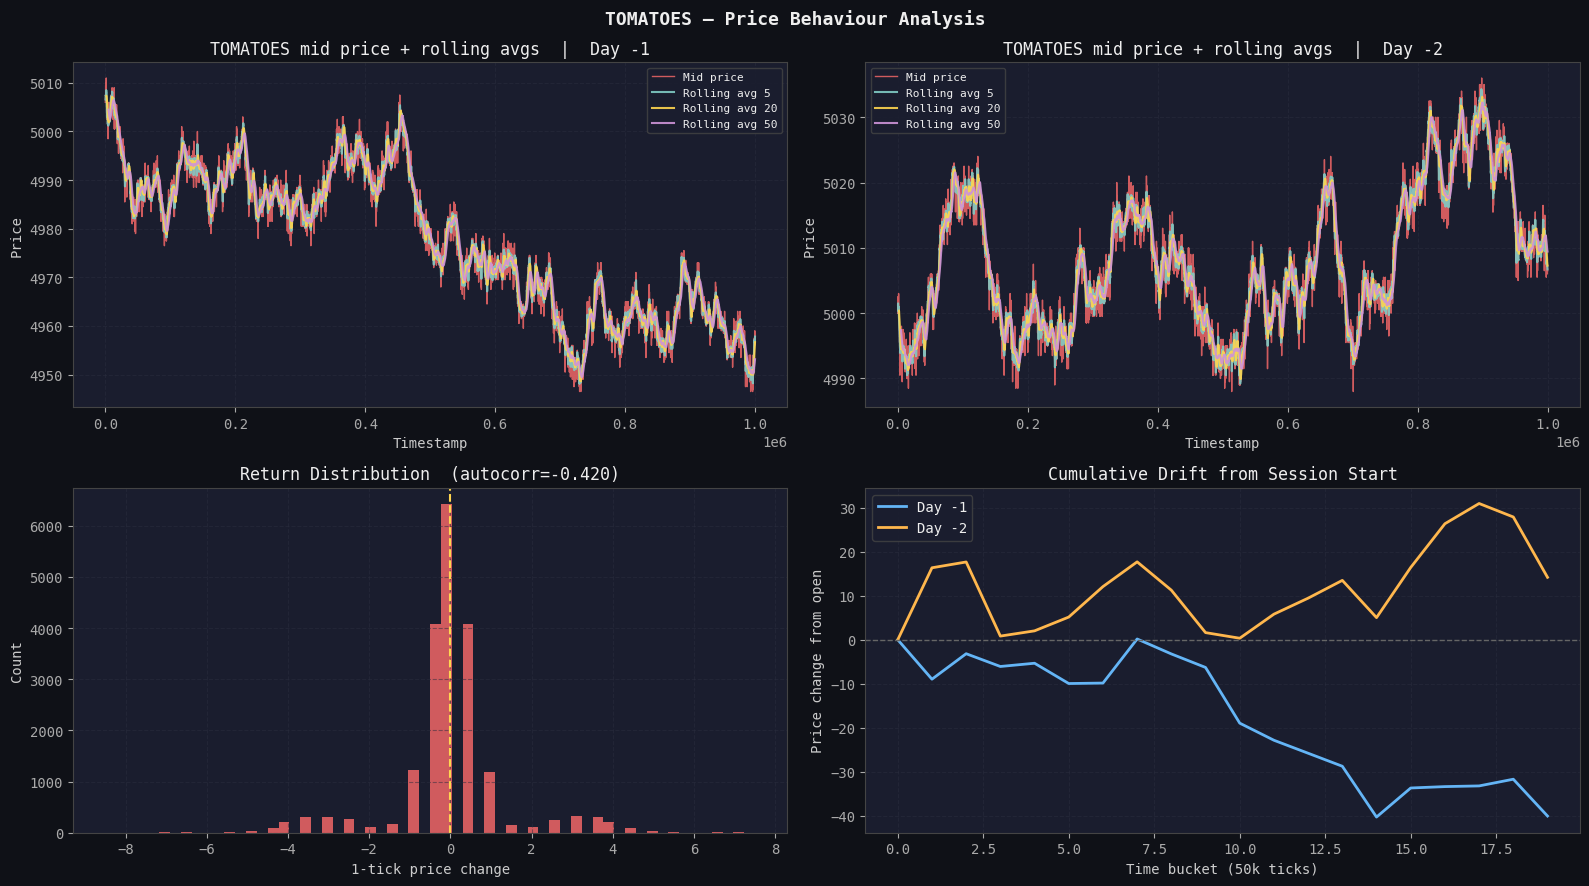

Saved: tomatoes_analysis.png


In [ ]:
# ══════════════════════════════════════════════════════════════════
# SECTION 6 — TOMATOES Deep Dive
# ══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
fig.suptitle("TOMATOES — Price Behaviour Analysis", fontsize=13, fontweight="bold")

# Plot 1 & 2: Price path with rolling mean overlay
for col, (label, df_day) in enumerate([("Day -1", p1), ("Day -2", p2)]):
    ax = axes[0][col]
    df = df_day[df_day["product"] == "TOMATOES"].sort_values("timestamp").copy()

    ax.plot(df["timestamp"], df["mid_price"],
            color=COLORS["TOMATOES"], lw=1, alpha=0.8, label="Mid price")
    for win, col_roll in [(5, "#80cbc4"), (20, "#ffd54f"), (50, "#ce93d8")]:
        ax.plot(df["timestamp"], df["mid_price"].rolling(win).mean(),
                color=col_roll, lw=1.5, alpha=0.9, label=f"Rolling avg {win}")
    ax.set_title(f"TOMATOES mid price + rolling avgs  |  {label}")
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Price")
    ax.legend(fontsize=8)
    ax.grid(True)

# Plot 3: Return distribution (shows mean-reversion)
ax = axes[1][0]
to_all = prices[prices["product"] == "TOMATOES"].sort_values(["day","timestamp"]).copy()
to_all["ret"] = to_all.groupby("day")["mid_price"].diff()
to_all["ret"].dropna().hist(bins=60, ax=ax, color=COLORS["TOMATOES"], alpha=0.8, edgecolor="none")
ac1 = to_all["ret"].autocorr(lag=1)
ax.set_title(f"Return Distribution  (autocorr={ac1:.3f})")
ax.set_xlabel("1-tick price change")
ax.set_ylabel("Count")
ax.axvline(0, color="#ffd54f", lw=1.5, ls="--")
ax.grid(True, axis="y")

# Plot 4: Drift by time bucket
ax = axes[1][1]
for label, df_day, color in [("Day -1", p1, COLORS["Day -1"]),
                               ("Day -2", p2, COLORS["Day -2"])]:
    df = df_day[df_day["product"] == "TOMATOES"].sort_values("timestamp").copy()
    df["bucket"] = df["timestamp"] // 50000
    bucket_mid = df.groupby("bucket")["mid_price"].mean()
    # Normalize to start at 0
    ax.plot(bucket_mid.index, bucket_mid.values - bucket_mid.iloc[0],
            color=color, lw=2, label=label)
ax.axhline(0, color="#666", lw=1, ls="--")
ax.set_title("Cumulative Drift from Session Start")
ax.set_xlabel("Time bucket (50k ticks)")
ax.set_ylabel("Price change from open")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig("tomatoes_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: tomatoes_analysis.png")


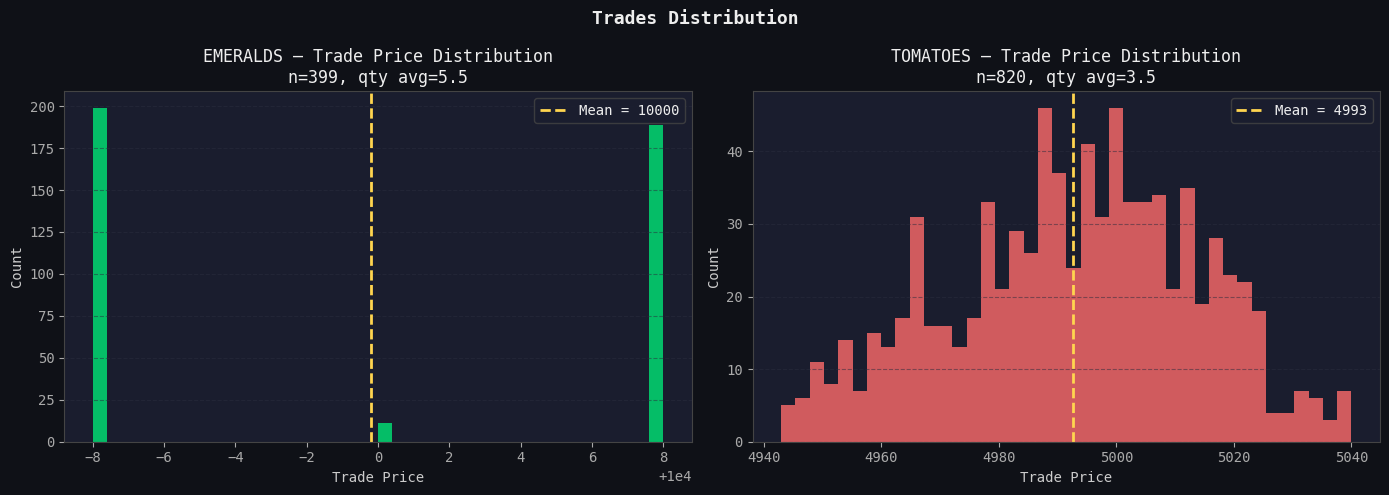

Saved: trades_analysis.png


In [ ]:
# ══════════════════════════════════════════════════════════════════
# SECTION 7 — Trades Analysis
# ══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Trades Distribution", fontsize=13, fontweight="bold")

for col, sym in enumerate(["EMERALDS", "TOMATOES"]):
    ax = axes[col]
    td = trades[trades["symbol"] == sym].copy()
    color = COLORS[sym]

    ax.hist(td["price"], bins=40, color=color, alpha=0.8, edgecolor="none")
    ax.axvline(td["price"].mean(), color="#ffd54f", lw=2, ls="--",
               label=f"Mean = {td['price'].mean():.0f}")
    ax.set_title(f"{sym} — Trade Price Distribution\n"
                 f"n={len(td)}, qty avg={td['quantity'].mean():.1f}")
    ax.set_xlabel("Trade Price")
    ax.set_ylabel("Count")
    ax.legend()
    ax.grid(True, axis="y")

plt.tight_layout()
plt.savefig("trades_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: trades_analysis.png")



In [ ]:
# ══════════════════════════════════════════════════════════════════
# SECTION 8 — Quote Width Sensitivity (TOMATOES)
# ══════════════════════════════════════════════════════════════════

print("\n" + "="*60)
print("TOMATOES: FILL RATE vs QUOTE WIDTH")
print("="*60)
print("How often does the market move ≥ W ticks (triggering a passive fill)?")

to_d1 = p1[p1["product"] == "TOMATOES"].sort_values("timestamp").copy()
to_d1["ret"] = to_d1["mid_price"].diff()

print(f"\n{'Width':>6} | {'Buy fills (Day-1)':>17} | {'Sell fills (Day-1)':>18}")
print("-" * 50)
for W in range(1, 10):
    bf = (to_d1["ret"] <= -W).sum()
    sf = (to_d1["ret"] >=  W).sum()
    print(f"  W={W:>2}  |  {bf:>8} ({100*bf/len(to_d1):>4.1f}%)     |  {sf:>8} ({100*sf/len(to_d1):>4.1f}%)")


TOMATOES: FILL RATE vs QUOTE WIDTH
How often does the market move ≥ W ticks (triggering a passive fill)?

 Width | Buy fills (Day-1) | Sell fills (Day-1)
--------------------------------------------------
  W= 1  |      1370 (13.7%)     |      1346 (13.5%)
  W= 2  |       671 ( 6.7%)     |       666 ( 6.7%)
  W= 3  |       486 ( 4.9%)     |       477 ( 4.8%)
  W= 4  |       170 ( 1.7%)     |       168 ( 1.7%)
  W= 5  |        26 ( 0.3%)     |        23 ( 0.2%)
  W= 6  |         7 ( 0.1%)     |         8 ( 0.1%)
  W= 7  |         3 ( 0.0%)     |         3 ( 0.0%)
  W= 8  |         0 ( 0.0%)     |         0 ( 0.0%)
  W= 9  |         0 ( 0.0%)     |         0 ( 0.0%)
